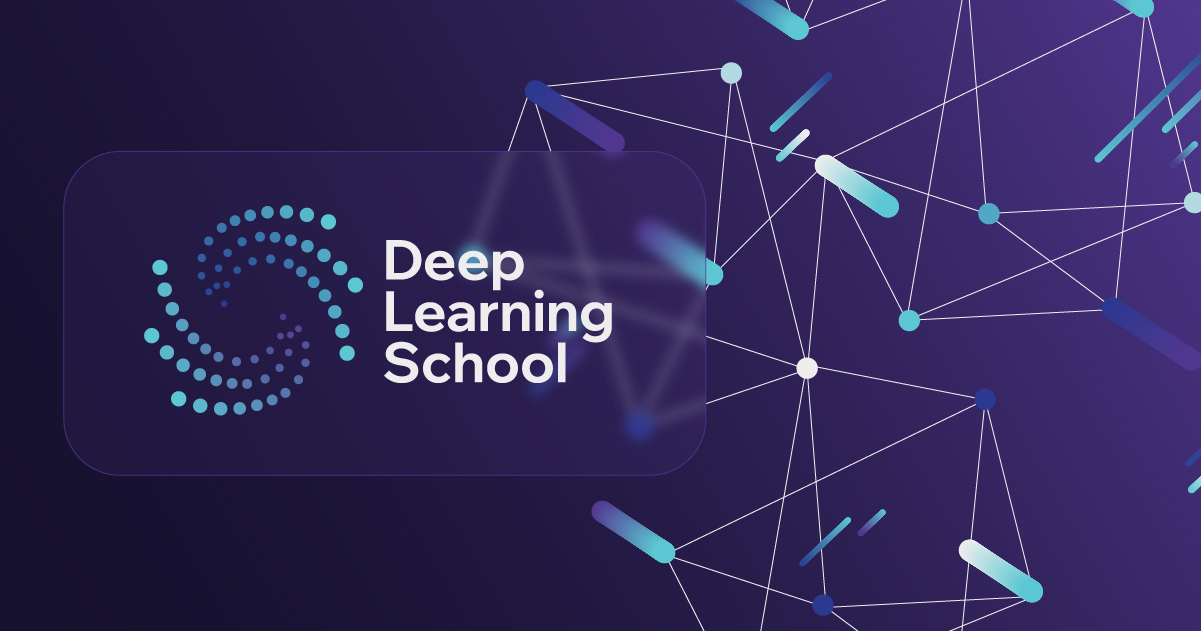


# Домашнее задание "Варианционные автоэнкодеры"

В этом домашнем задании вам предстоит реализовать несколько версий автоэнкодера для работы с изображениями.

Вы научитесь добавлять улыбку на фотографии людей, изменяя их исходное выражение лица с помощью обученной модели. А также, обучите ваш автоэнкодер генерировать изображения рукописных цифр.

# Часть 1. Vanilla Autoencoder (10 баллов)

## 1.1. Подготовка данных (1 балл)


Перед тем, как начинать работу с моделями нужно подготовить данные.

In [ ]:
import numpy as np
from torch.autograd import Variable
from torchvision import datasets
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data_utils
import torch
import matplotlib.pyplot as plt

import os
import pandas as pd
import skimage.io
from skimage.transform import resize

import imageio
from PIL import Image
import kagglehub

%matplotlib inline

В этом задании вам предстоить работать с датасетом [LFW (Labeled Faces in the Wild)](https://datasets.activeloop.ai/docs/ml/datasets/lfw-dataset/#:~:text=What%20is%20LFW%20Dataset%3F,commercial%20algorithms%20prior%20to%20release).

In [ ]:
# Скачиваем картинки
images_path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
print("Path to dataset files:", images_path)

Using Colab cache for faster access to the 'lfw-dataset' dataset.
Path to dataset files: /kaggle/input/lfw-dataset


In [ ]:
# Скачиваем атрибуты
attrs_path = kagglehub.dataset_download("averkij/lfw-attributes")
print("Path to dataset files:", attrs_path)

Using Colab cache for faster access to the 'lfw-attributes' dataset.
Path to dataset files: /kaggle/input/lfw-attributes


In [ ]:
DATASET_PATH ="/kaggle/input/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled/"
ATTRIBUTES_PATH = "/kaggle/input/lfw-attributes/lfw_attributes.txt"

In [ ]:
def fetch_dataset(dx=80, dy=80, dimx=45, dimy=45):

    df_attrs = pd.read_csv(ATTRIBUTES_PATH, sep='\t', skiprows=1,)
    df_attrs = pd.DataFrame(df_attrs.iloc[:, :-1].values, columns = df_attrs.columns[1:])

    photo_ids = []
    for dirpath, dirnames, filenames in os.walk(DATASET_PATH):
        for fname in filenames:
            if fname.endswith(".jpg"):
                fpath = os.path.join(dirpath, fname)
                photo_id = fname[:-4].replace('_', ' ').split()
                person_id = ' '.join(photo_id[:-1])
                photo_number = int(photo_id[-1])
                photo_ids.append({'person': person_id,'imagenum': photo_number, 'photo_path': fpath})

    photo_ids = pd.DataFrame(photo_ids)
    df = pd.merge(df_attrs,photo_ids,on=('person', 'imagenum'))

    assert len(df) == len(df_attrs), "Потеряны данные при объединении датафреймов!"

    images = df['photo_path'].apply(imageio.imread)\
                                .apply(lambda img:img[dy:-dy, dx:-dx])\
                                .apply(lambda img: np.array(Image.fromarray(img).resize([dimx, dimy])) )

    images = np.stack(images.values).astype('uint8')
    attrs = df.drop(["photo_path","person","imagenum"],axis=1)

    return images, attrs

In [ ]:
# Обратите внимание, что датасет представляет собой не только картинки, но и атрибуты
# Атрибуты понадобятся в конце этого задания

images, attrs = fetch_dataset()


Разбейте датасет изображений и атрибутов на train и val, выведите несколько картинок в output, чтобы посмотреть, как они выглядят, и приведите картинки к тензорам pytorch, чтобы можно было скормить их сети:

In [ ]:
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader

# 1. Нормализуем в [0, 1] и приведём к формату (N, C, H, W)
images_np = images.astype('float32') / 255.0  # [0, 1]
images_np = np.transpose(images_np, (0, 3, 1, 2))  # (N, 45, 45, 3) → (N, 3, 45, 45)

# 2. Преобразуем в тензоры
images_tensor = torch.from_numpy(images_np)
attrs_tensor = torch.from_numpy(attrs.values.astype('float32'))

# 3. Разбиваем на train/val
train_images, val_images, train_attrs, val_attrs = train_test_split(
    images_tensor, attrs_tensor, train_size=0.9, random_state=42, shuffle=True
)

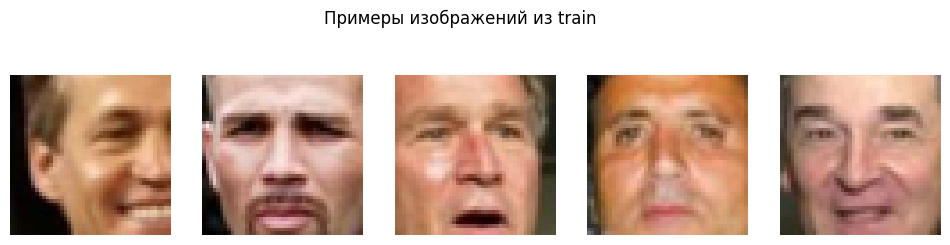

In [ ]:
# 4. Визуализация
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img = train_images[i].permute(1, 2, 0).numpy()  # (3, 45, 45) → (45, 45, 3)
    axes[i].imshow(img)
    axes[i].axis('off')
plt.suptitle("Примеры изображений из train")
plt.show()

In [ ]:
# 5. DataLoader'ы
train_dataset = TensorDataset(train_images, train_attrs)
val_dataset = TensorDataset(val_images, val_attrs)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

## 1.2. Архитектура модели (2 балла)
В этом разделе вы напишите и обучите обычный автоэнкодер.



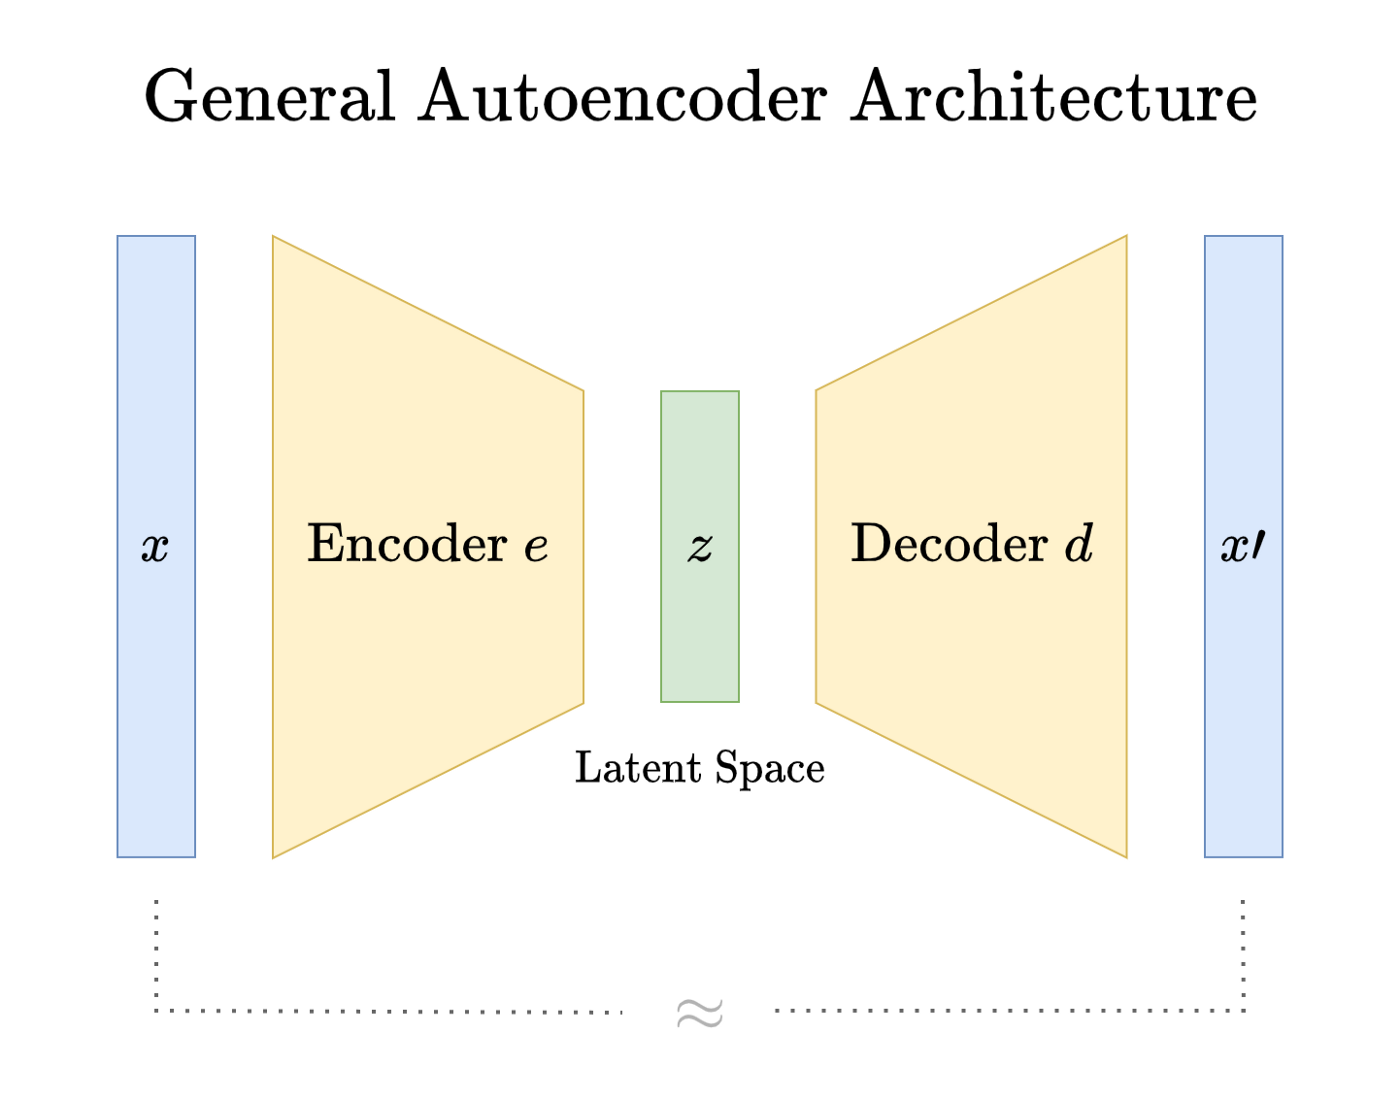

In [ ]:
dim_code = 128

Реализуем autoencoder. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Экспериментируйте!

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: 3 → 32 → 64 → 128 → dim_code
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # 45x45 → 23x23
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 23x23 → 12x12
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 12x12 → 6x6
            nn.ReLU(),
            nn.Conv2d(128, dim_code, kernel_size=6, stride=1, padding=0),  # 6x6 → 1x1
            nn.ReLU()
        )
        # Decoder: dim_code → 128 → 64 → 32 → 3
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(dim_code, 128, kernel_size=6, stride=1, padding=0),  # 1x1 → 6x6
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 6x6 → 12x12
            nn.ReLU(),
            # Для 12x12 → 23x23 используем output_padding=0
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),  # 12x12 → 23x23
            nn.ReLU(),
            # Для 23x23 → 45x45 используем kernel_size=3, stride=2, padding=1
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=0),  # 23x23 → 45x45
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        latent_code = latent.view(latent.size(0), -1)
        return reconstruction, latent_code

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
criterion = nn.MSELoss()

autoencoder = Autoencoder().to(device)

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3)


## 1.3 Обучение (2 балла)

Осталось написать код обучения автоэнкодера. При этом было бы неплохо в процессе иногда смотреть, как автоэнкодер реконструирует изображения на данном этапе обучения. Наример, после каждой эпохи (прогона train выборки через автоэнкодер) можно смотреть, какие реконструкции получились для каких-то изображений val выборки.

А, ну еще было бы неплохо выводить графики train и val лоссов в процессе тренировки =)

Epoch [1/30], Train Loss: 0.016817, Val Loss: 0.008813


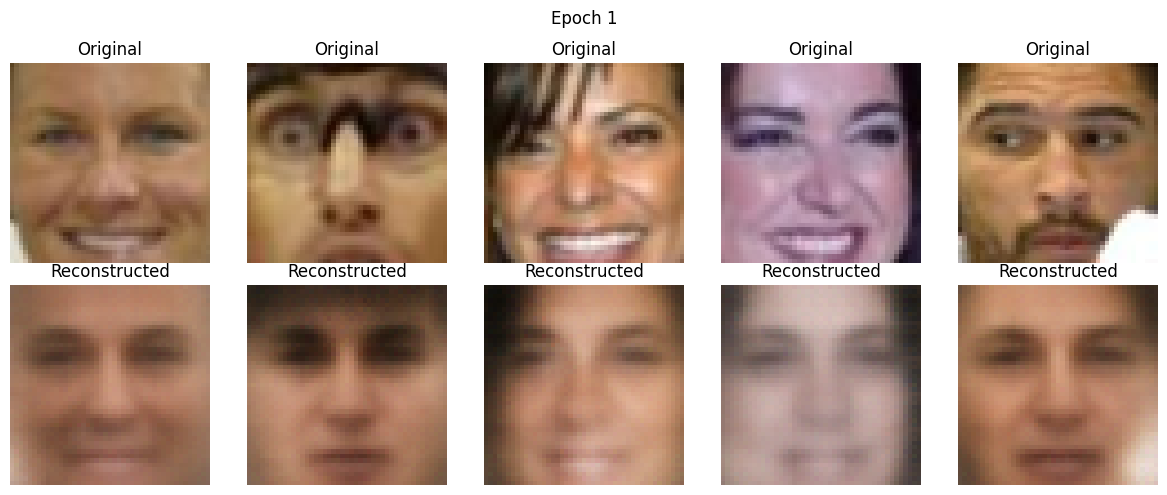

Epoch [10/30], Train Loss: 0.003429, Val Loss: 0.003449


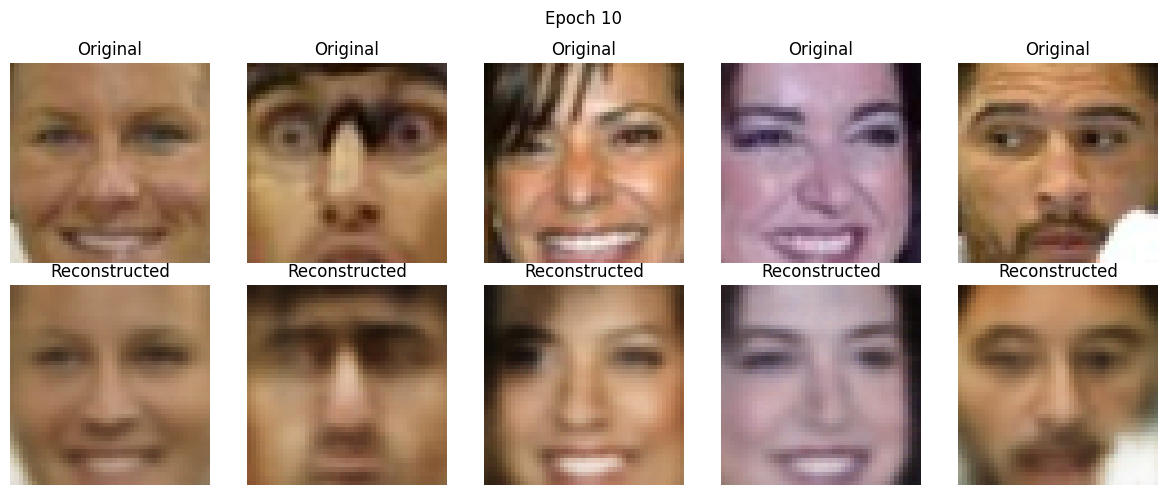

Epoch [20/30], Train Loss: 0.003079, Val Loss: 0.003224


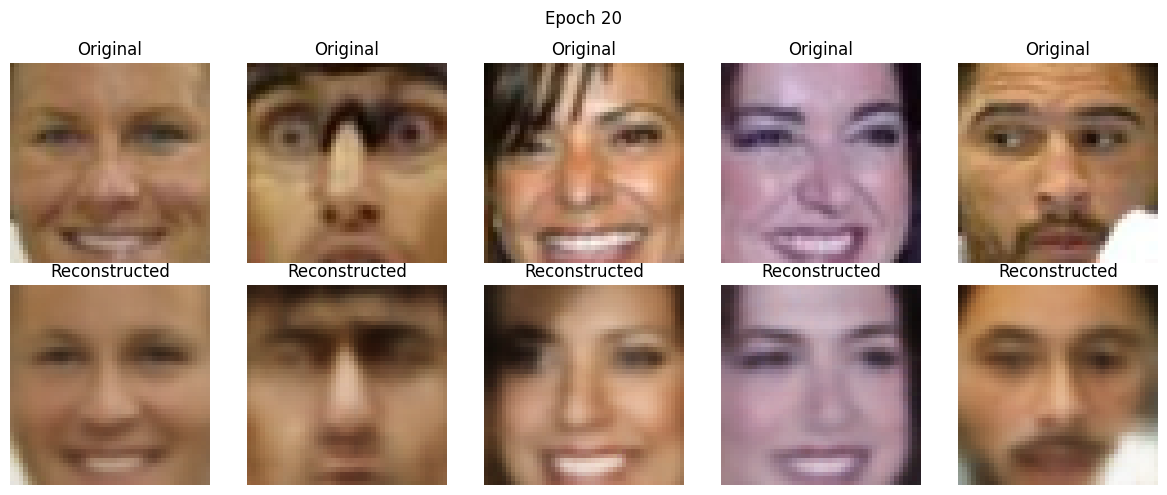

Epoch [30/30], Train Loss: 0.002918, Val Loss: 0.003186


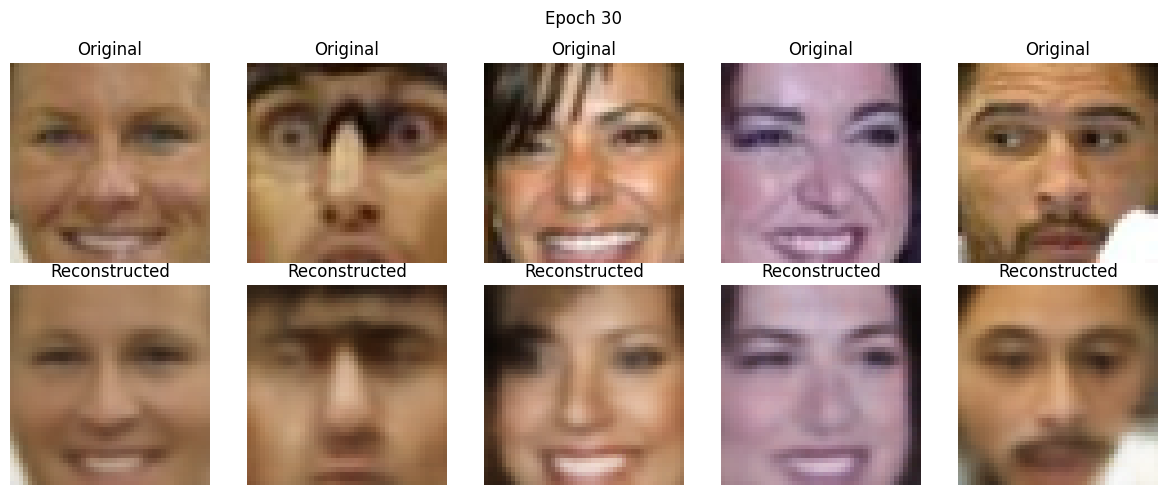

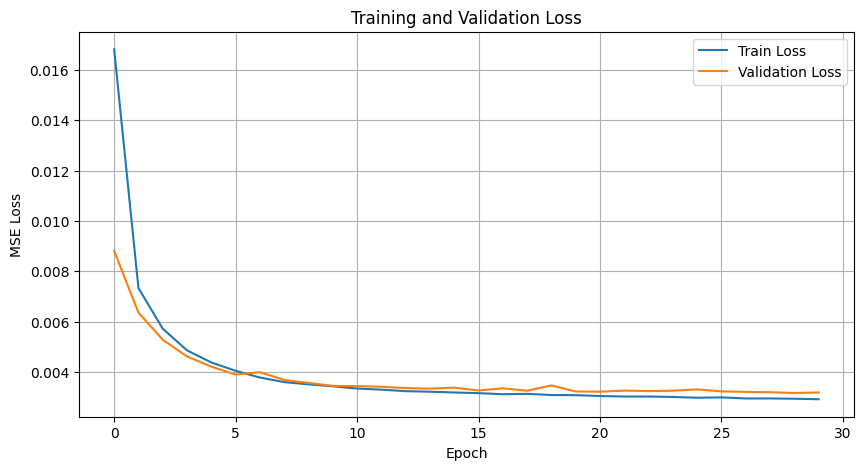

In [ ]:
# Гиперпараметры
n_epochs = 30
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    # Обучение
    autoencoder.train()
    train_loss = 0.0
    for batch in train_loader:
        images = batch[0].to(device)  # (B, 3, 45, 45)
        optimizer.zero_grad()
        reconstructions, _ = autoencoder(images)
        loss = criterion(reconstructions, images)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Валидация
    autoencoder.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            images = batch[0].to(device)
            reconstructions, _ = autoencoder(images)
            loss = criterion(reconstructions, images)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    # Визуализация каждые 10 эпох
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1}/{n_epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')

        autoencoder.eval()
        with torch.no_grad():
            # Берём первые 5 изображений из валидационной выборки
            sample_batch = next(iter(val_loader))[0][:5].to(device)
            recon, _ = autoencoder(sample_batch)

            # Переводим в numpy и в формат (H, W, C) для отображения
            originals = sample_batch.cpu().permute(0, 2, 3, 1).numpy()  # (5, 45, 45, 3)
            reconstructions = recon.cpu().permute(0, 2, 3, 1).numpy()   # (5, 45, 45, 3)

        # Визуализация
        fig, axes = plt.subplots(2, 5, figsize=(12, 5))
        for i in range(5):
            axes[0, i].imshow(originals[i])
            axes[0, i].set_title("Original")
            axes[0, i].axis('off')

            axes[1, i].imshow(reconstructions[i])
            axes[1, i].set_title("Reconstructed")
            axes[1, i].axis('off')

        plt.suptitle(f'Epoch {epoch+1}')
        plt.tight_layout()
        plt.show()

# График лоссов
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

Давайте посмотрим, как наш тренированный автоэнкодер кодирует и восстанавливает картинки:

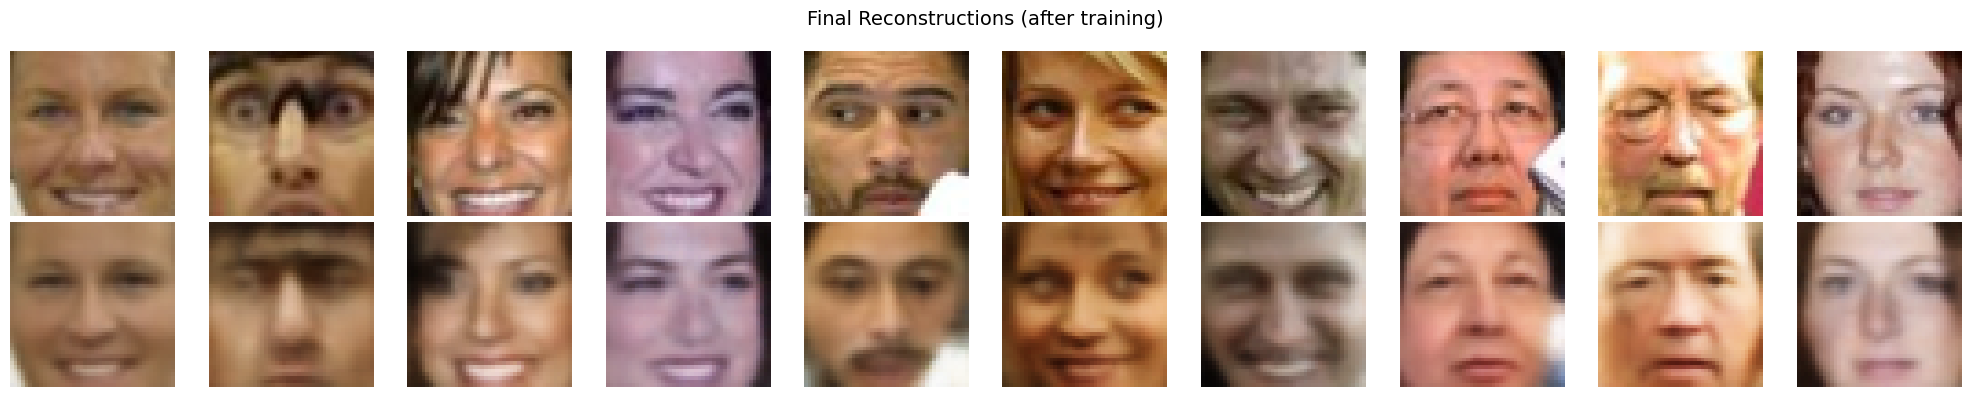

In [ ]:
# Вывод первых 10 изображений и их реконструкций из val
autoencoder.eval()
with torch.no_grad():
    val_iter = iter(val_loader)
    batch = next(val_iter)
    originals = batch[0][:10].to(device)
    reconstructions, _ = autoencoder(originals)

    # Преобразуем в формат для отображения (H, W, C)
    originals = originals.cpu().permute(0, 2, 3, 1).numpy()
    reconstructions = reconstructions.cpu().permute(0, 2, 3, 1).numpy()

# Отображаем
fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(originals[i])
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructions[i])
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Reconstructed', fontsize=12)
plt.suptitle('Final Reconstructions (after training)', fontsize=14)
plt.tight_layout()
plt.show()

Что вы можете сказать про результат?

**Ответ:** Общая структура лица восстанавливается, все части лица сохранены, их положения сохранены. Цвет изображений перадается хорошо. Однако четкость изображений потеряна, мелкие детали (такие как направление взгляда, например) не сохраняются.

## 1.4. Sampling (2 балла)

Давайте теперь будем не просто брать картинку, прогонять ее через автоэнкодер и получать реконструкцию, а попробуем создать что-то НОВОЕ!

Давайте возьмем и подсунем декодеру какие-нибудь сгенерированные нами векторы (например, из нормального распределения) и посмотрим на результат реконструкции декодера:

__Подсказка:__ Если вместо лиц у вас выводится непонятно что, попробуйте посмотреть, как выглядят латентные векторы картинок из датасета. Так как в обучении нейронных сетей есть определенная доля рандома, векторы латентного слоя могут быть распределены НЕ как `np.random.randn(25, <latent_space_dim>)`. А чтобы у нас получались лица при запихивании вектора декодеру, вектор должен быть распределен так же, как латентные векторы реальных фоток. Так что в таком случае придется рандом немного подогнать.

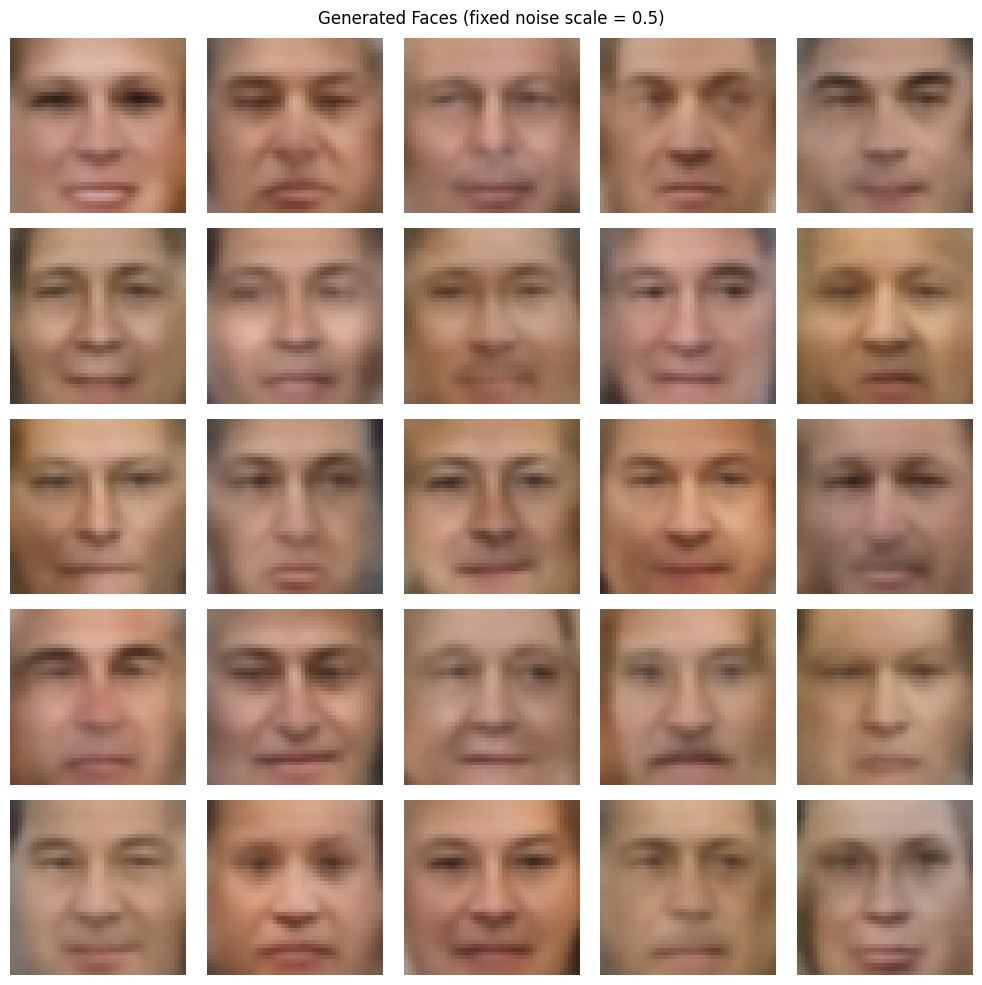

In [ ]:
# Собираем все латентные коды
autoencoder.eval()
all_latents = []
with torch.no_grad():
    for batch in train_loader:
        imgs = batch[0].to(device)
        _, z = autoencoder(imgs)
        all_latents.append(z.cpu())
all_latents = torch.cat(all_latents, dim=0)

latent_mean = all_latents.mean(dim=0).numpy()

noise_scale = 0.5

z = np.random.randn(25, dim_code) * noise_scale + latent_mean
z = torch.from_numpy(z).float().to(device).view(-1, dim_code, 1, 1)

with torch.no_grad():
    gen = autoencoder.decoder(z)
    gen = torch.clamp(gen, 0, 1)

# Визуализация
gen_imgs = gen.cpu().permute(0, 2, 3, 1).numpy()
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(gen_imgs[i])
    plt.axis('off')
plt.suptitle(f"Generated Faces (fixed noise scale = {noise_scale})")
plt.tight_layout()
plt.show()

In [ ]:
# при большем шуме лица получаются слишком искаженными

## 1.5 Time to make fun! (3 балла)

Давайте научимся пририсовывать людям улыбки =)

<img src="https://i.imgur.com/tOE9rDK.png" alt="linear" width="700" height="400">

План такой:

1. Нужно выделить "вектор улыбки": для этого нужно из выборки изображений найти несколько (~15) людей с улыбками и столько же без.

Найти людей с улыбками вам поможет файл с атрибутами, скачанный вместе с картинками. В нем указаны имена изображений и присутствубщие атрибуты (улыбки, очки и прочее интересное).

2. Вычислить латентный вектор для всех улыбающихся людей (прогнать их через encoder) и то же для всех грустненьких.

3. Вычислить, собственно, вектор улыбки -- посчитать разность между средним латентным вектором улыбающихся людей и средним латентным вектором грустных людей.

4. А теперь приделаем улыбку грустному человеку: добавим полученный в пункте 3 вектор к латентному вектору грустного человека и прогоним полученный вектор через decoder. Получим того же человека, но уже не грустненького!

In [ ]:
attrs

,Male,Asian,White,Black,Baby,Child,Youth,Middle Aged,Senior,Black Hair,...,Pale Skin,5 o' Clock Shadow,Strong Nose-Mouth Lines,Wearing Lipstick,Flushed Face,High Cheekbones,Brown Eyes,Wearing Earrings,Wearing Necktie,Wearing Necklace
0,1.568346,-1.889043,1.737203,-0.929729,-1.471799,-0.19558,-0.835609,-0.351468,-1.012533,-0.719593,...,0.361738,1.166118,-1.164916,-1.13999,-2.371746,-1.299932,-0.414682,-1.144902,0.694007,-0.826609
1,0.169851,-0.982408,0.422709,-1.282184,-1.36006,-0.867002,-0.452293,-0.197521,-0.956073,-0.802107,...,-0.832036,-0.39768,0.87416,-0.945431,-0.268649,-0.006244,-0.030406,-0.480128,0.66676,-0.496559
2,0.997749,-1.364195,-0.157377,-0.756447,-1.891825,-0.871526,-0.862893,0.031445,-1.341523,-0.090037,...,1.549743,1.884745,-0.999765,-1.359858,-1.912108,-1.095634,0.915126,-0.572332,0.144262,-0.841231
3,1.122719,-1.997799,1.916144,-2.514214,-2.580071,-1.404239,0.057551,0.000196,-1.273512,-1.431462,...,0.567822,-0.176089,1.108125,-1.600944,-3.264613,0.813418,0.308631,-0.848693,0.475941,-0.447025
4,1.078214,-2.008098,1.676211,-2.278056,-2.651845,-1.348408,0.649089,0.017656,-1.889111,-1.857213,...,-1.461474,-0.955283,0.119113,-1.128176,-3.161048,0.08268,-0.439614,-0.359859,-0.760774,-0.410152
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13138,-0.205363,-0.202842,-1.232735,-1.409125,-1.804858,0.287268,-0.521815,-0.789165,-1.008119,0.531813,...,-0.867156,-0.879554,-0.179497,0.323676,-2.188852,-1.169369,0.924397,-0.217415,-0.414024,-0.495178
13139,1.957472,-2.47247,-1.307994,-0.671636,-1.960125,-0.838803,-1.365955,0.510448,-1.262193,0.418947,...,-2.487289,2.608861,-0.95419,-1.599463,-1.23822,-1.187034,1.87413,-0.832614,0.152785,-0.554331
13140,-0.037001,-1.16415,0.228494,0.187503,-1.836475,-0.958412,-0.669697,-0.48033,0.493433,-1.893151,...,-1.938639,-0.49108,0.495067,-0.524767,-1.073731,0.11101,0.976262,-0.453027,-0.399981,-1.078655
13141,0.282219,-0.396198,1.27047,-1.981209,-1.70294,-1.507203,-2.330721,-0.295928,1.056618,-1.613698,...,-0.662101,-1.692131,1.284772,-0.80818,-0.710051,0.694621,0.936065,-0.7675,1.14693,-0.26094


In [ ]:
attrs['Smiling']

,Smiling
0,-0.86499
1,0.798544
2,0.172817
3,0.563327
4,0.507786
...,...
13138,-1.001434
13139,-0.64957
13140,0.475018
13141,0.741653


In [ ]:
smiling_values = attrs['Smiling'].values

smiling_indices = np.where(smiling_values > 0)[0]
not_smiling_indices = np.where(smiling_values < 0)[0]

print(f"Улыбающихся: {len(smiling_indices)}")
print(f"Не улыбающихся: {len(not_smiling_indices)}")

Улыбающихся: 5432
Не улыбающихся: 7711


In [ ]:
# Топ-15 самых улыбающихся
top_smiling = np.argsort(smiling_values)[-15:]

# Топ-15 самых грустных
top_not_smiling = np.argsort(smiling_values)[:15]

In [ ]:
autoencoder.eval()

# Функция для получения латентного вектора по индексам
def get_latent_vectors(indices):
    imgs = images_tensor[indices].to(device)
    with torch.no_grad():
        _, latents = autoencoder(imgs)
    return latents.cpu().numpy()

# Получаем латентные векторы
latents_smiling = get_latent_vectors(top_smiling)        # (15, dim_code)
latents_not_smiling = get_latent_vectors(top_not_smiling)  # (15, dim_code)

In [ ]:
# Средние латентные векторы
mean_smiling = np.mean(latents_smiling, axis=0)        # (dim_code,)
mean_not_smiling = np.mean(latents_not_smiling, axis=0)  # (dim_code,)

# Вектор улыбки = среднее улыбающихся - среднее не улыбающихся
smile_vector = mean_smiling - mean_not_smiling  # (dim_code,)

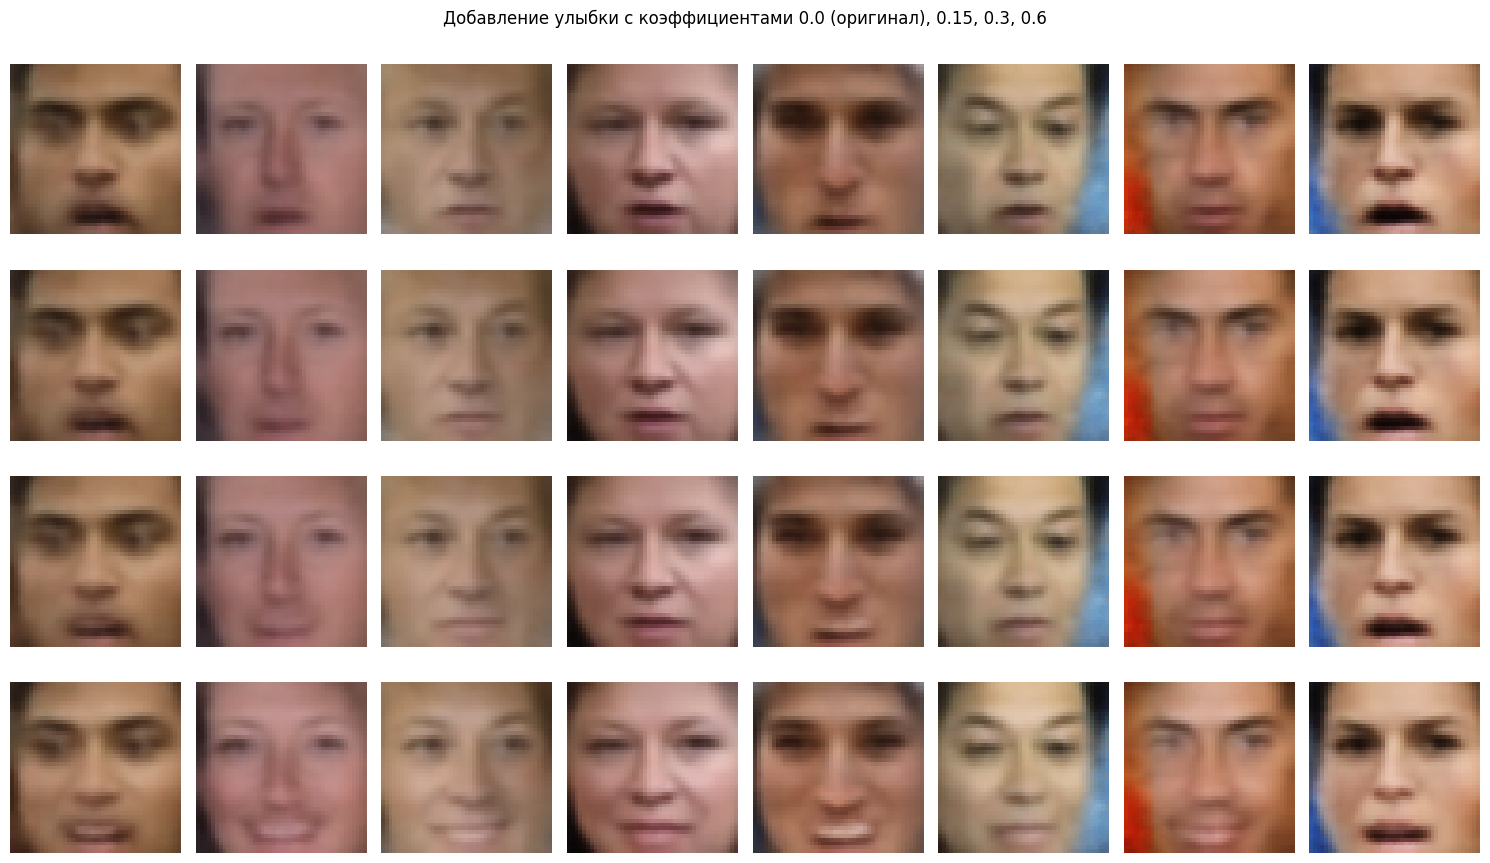

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(15, 9))

for i in range(8):
    idx = top_not_smiling[i]
    img = images_tensor[idx:idx+1].to(device)

    with torch.no_grad():
        _, latent = autoencoder(img)

        # Пробуем разные коэффициенты
        for j, coeff in enumerate([0.0, 0.15, 0.3, 0.6]):
            latent_new = latent.cpu().numpy().squeeze() + coeff * smile_vector
            latent_new_tensor = torch.FloatTensor(latent_new).unsqueeze(0).unsqueeze(-1).unsqueeze(-1).to(device)
            rec = autoencoder.decoder(latent_new_tensor)
            rec = rec.cpu().numpy().squeeze()

            axes[j, i].imshow(rec.transpose(1, 2, 0))
            if i == 0:
                axes[j, i].set_ylabel(f"Coeff: {coeff}")
            axes[j, i].axis('off')

plt.suptitle("Добавление улыбки с коэффициентами 0.0 (оригинал), 0.15, 0.3, 0.6")
plt.tight_layout()
plt.show()

In [ ]:
# Мужчины превращаются в женщин после преобразований.
# Скорее всего, выборка с улцбающимимся людьм в основном состояла из женщин, а с неулыбающимися - из мужчин.
# Надо это исправить, сделаем более сбалансированную выборку.

In [ ]:
# Найдем индексы атрибутов
smiling_idx = attrs.columns.get_loc('Smiling')
male_idx = attrs.columns.get_loc('Male')

# Определим пороговые значения
smiling_threshold = 0.5  # Значение больше этого - улыбается
male_threshold = 0.5     # Значение больше этого - мужчина

# 1. Улыбающиеся мужчины (Male > 0.5, Smiling > 0.5)
smiling_male_indices = np.where(
    (attrs.iloc[:, male_idx] > male_threshold) &
    (attrs.iloc[:, smiling_idx] > smiling_threshold)
)[0]

# 2. Улыбающиеся женщины (Male < -0.5, Smiling > 0.5)
smiling_female_indices = np.where(
    (attrs.iloc[:, male_idx] < -male_threshold) &
    (attrs.iloc[:, smiling_idx] > smiling_threshold)
)[0]

# 3. Не улыбающиеся мужчины (Male > 0.5, Smiling < -0.5)
not_smiling_male_indices = np.where(
    (attrs.iloc[:, male_idx] > male_threshold) &
    (attrs.iloc[:, smiling_idx] < -smiling_threshold)
)[0]

# 4. Не улыбающиеся женщины (Male < -0.5, Smiling < -0.5)
not_smiling_female_indices = np.where(
    (attrs.iloc[:, male_idx] < -male_threshold) &
    (attrs.iloc[:, smiling_idx] < -smiling_threshold)
)[0]

print(f"Найдено:")
print(f"  Улыбающихся мужчин: {len(smiling_male_indices)}")
print(f"  Улыбающихся женщин: {len(smiling_female_indices)}")
print(f"  Не улыбающихся мужчин: {len(not_smiling_male_indices)}")
print(f"  Не улыбающихся женщин: {len(not_smiling_female_indices)}")

# Берем по 8 из каждой группы (или сколько есть, если меньше)
n_samples = 8

# Функция для безопасного выбора n элементов
def safe_sample(indices, n_samples):
    if len(indices) >= n_samples:
        return np.random.choice(indices, n_samples, replace=False)
    else:
        print(f"  Внимание: в группе только {len(indices)} элементов, берем все")
        return indices

# Создаем сбалансированные выборки
balanced_smiling = np.concatenate([
    safe_sample(smiling_male_indices, n_samples),
    safe_sample(smiling_female_indices, n_samples)
])

balanced_not_smiling = np.concatenate([
    safe_sample(not_smiling_male_indices, n_samples),
    safe_sample(not_smiling_female_indices, n_samples)
])

print(f"\nСбалансированные выборки:")
print(f"  Улыбающихся: {len(balanced_smiling)} (из них мужчин: {len(balanced_smiling)//2})")
print(f"  Не улыбающихся: {len(balanced_not_smiling)} (из них мужчин: {len(balanced_not_smiling)//2})")

# Проверим балансировку
print(f"\nПроверка балансировки:")
print(f"  Улыбающиеся - мужчин: {np.sum(attrs.iloc[balanced_smiling, male_idx] > 0)}")
print(f"  Улыбающиеся - женщин: {np.sum(attrs.iloc[balanced_smiling, male_idx] < 0)}")
print(f"  Не улыбающиеся - мужчин: {np.sum(attrs.iloc[balanced_not_smiling, male_idx] > 0)}")
print(f"  Не улыбающиеся - женщин: {np.sum(attrs.iloc[balanced_not_smiling, male_idx] < 0)}")

Найдено:
  Улыбающихся мужчин: 1923
  Улыбающихся женщин: 1231
  Не улыбающихся мужчин: 4480
  Не улыбающихся женщин: 387

Сбалансированные выборки:
  Улыбающихся: 16 (из них мужчин: 8)
  Не улыбающихся: 16 (из них мужчин: 8)

Проверка балансировки:
  Улыбающиеся - мужчин: 8
  Улыбающиеся - женщин: 8
  Не улыбающиеся - мужчин: 8
  Не улыбающиеся - женщин: 8


In [ ]:
# Получаем латентные векторы для сбалансированных выборок
latents_smiling_balanced = get_latent_vectors(balanced_smiling)
latents_not_smiling_balanced = get_latent_vectors(balanced_not_smiling)

# Вычисляем средние и вектор улыбки
mean_smiling_balanced = np.mean(latents_smiling_balanced, axis=0)
mean_not_smiling_balanced = np.mean(latents_not_smiling_balanced, axis=0)

smile_vector_balanced = mean_smiling_balanced - mean_not_smiling_balanced

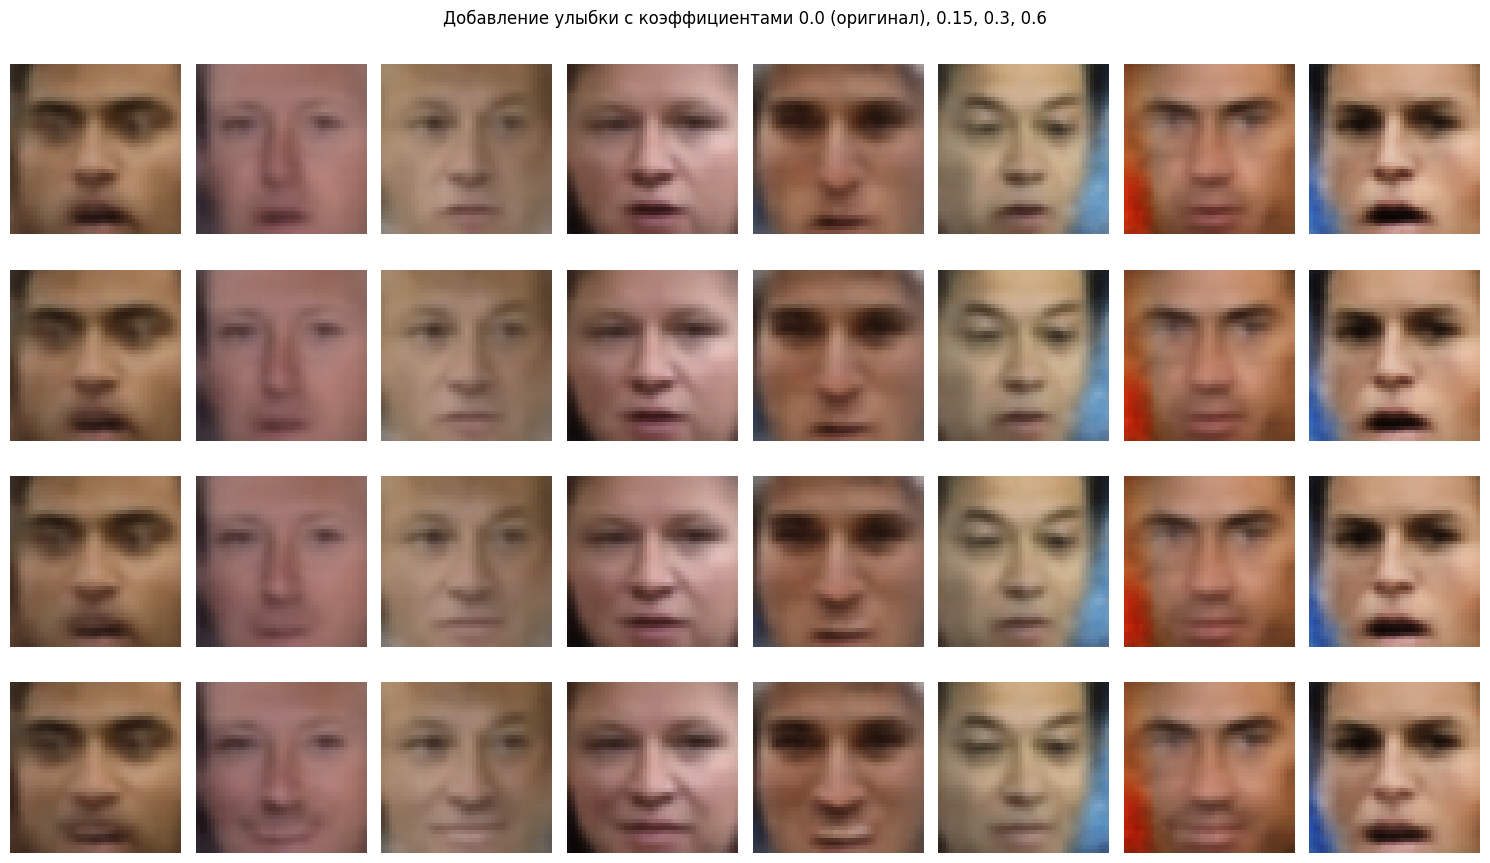

In [ ]:
fig, axes = plt.subplots(4, 8, figsize=(15, 9))

for i in range(8):
    idx = top_not_smiling[i]
    img = images_tensor[idx:idx+1].to(device)

    with torch.no_grad():
        _, latent = autoencoder(img)

        # Пробуем разные коэффициенты
        for j, coeff in enumerate([0.0, 0.15, 0.3, 0.6]):
            latent_new = latent.cpu().numpy().squeeze() + coeff * smile_vector_balanced
            latent_new_tensor = torch.FloatTensor(latent_new).unsqueeze(0).unsqueeze(-1).unsqueeze(-1).to(device)
            rec = autoencoder.decoder(latent_new_tensor)
            rec = rec.cpu().numpy().squeeze()

            axes[j, i].imshow(rec.transpose(1, 2, 0))
            if i == 0:
                axes[j, i].set_ylabel(f"Coeff: {coeff}")
            axes[j, i].axis('off')

plt.suptitle("Добавление улыбки с коэффициентами 0.0 (оригинал), 0.15, 0.3, 0.6")
plt.tight_layout()
plt.show()

In [ ]:
# Теперь стало получше

Вуаля! Вы восхитительны!

Теперь вы можете пририсовывать людям не только улыбки, но и много чего другого -- закрывать/открывать глаза, пририсовывать очки... В общем, все, на что хватит фантазии и на что есть атрибуты в `attrs`:)

# Часть 2: Variational Autoencoder (10 баллов)

Займемся обучением вариационных автоэнкодеров — проапгрейженной версии AE. Обучать будем на датасете MNIST, содержащем написанные от руки цифры от 0 до 9

In [ ]:
from torchvision import datasets, transforms

batch_size = 32
# MNIST Dataset
train_dataset = datasets.MNIST(root='./mnist_data/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='./mnist_data/', train=False, transform=transforms.ToTensor(), download=False)

# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 129kB/s]
100%|██████████| 1.65M/1.65M [00:02<00:00, 676kB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


## 2.1 Архитектура модели и обучение (2 балла)

Реализуем VAE. Архитектуру (conv, fully-connected, ReLu, etc) можете выбирать сами. Рекомендуем пользоваться более сложными моделями, чем та, что была на семинаре:) Экспериментируйте!

In [ ]:
class VAE(nn.Module):
  def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.conv1 = nn.Conv2d(1, 32, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)
        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 64 * 7 * 7)
        self.deconv1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)
        self.deconv2 = nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1)

  def encode(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logsigma = self.fc_logvar(x)

        return mu, logsigma

  def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

  def decode(self, z):
        reconstruction = self.fc_decode(z)
        reconstruction = reconstruction.view(reconstruction.size(0), 64, 7, 7)
        reconstruction = F.relu(self.deconv1(reconstruction))
        reconstruction = torch.sigmoid(self.deconv2(reconstruction))
        return reconstruction

  def forward(self, x):
        mu, logsigma = self.encode(x)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z)
        return mu, logsigma, reconstruction

Определим лосс и его компоненты для VAE:

Надеюсь, вы уже прочитали материал в towardsdatascience (или еще где-то) про VAE и знаете, что лосс у VAE состоит из двух частей: KL и log-likelihood.

Общий лосс будет выглядеть так:

$$\mathcal{L} = -D_{KL}(q_{\phi}(z|x)||p(z)) + \log p_{\theta}(x|z)$$

Формула для KL-дивергенции:

$$D_{KL} = -\frac{1}{2}\sum_{i=1}^{dimZ}(1+log(\sigma_i^2)-\mu_i^2-\sigma_i^2)$$

В качестве log-likelihood возьмем привычную нам кросс-энтропию.

In [ ]:
def KL_divergence(mu, logsigma):
    """
    часть функции потерь, которая отвечает за "близость" латентных представлений разных людей
    """
    loss = -0.5 * torch.sum(1 + logsigma - mu.pow(2) - logsigma.exp())
    return loss

def log_likelihood(x, reconstruction):
    """
    часть функции потерь, которая отвечает за качество реконструкции
    """
    loss = F.binary_cross_entropy(reconstruction, x, reduction='sum')
    return loss

def loss_vae(x, mu, logsigma, reconstruction):
    return KL_divergence(mu, logsigma) + log_likelihood(x, reconstruction)

И обучим модель:

In [ ]:
criterion = loss_vae

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = VAE(latent_dim=20).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
n_epochs = 30
train_losses = []

for epoch in range(n_epochs):
    model.train()
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        mu, logvar, recon = model(data)
        loss = loss_vae(data, mu, logvar, recon)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}')

Epoch 1/30, Loss: 125.5644
Epoch 2/30, Loss: 108.2957
Epoch 3/30, Loss: 106.3383
Epoch 4/30, Loss: 105.1862
Epoch 5/30, Loss: 104.3839
Epoch 6/30, Loss: 103.8214
Epoch 7/30, Loss: 103.3163
Epoch 8/30, Loss: 102.8663
Epoch 9/30, Loss: 102.5555
Epoch 10/30, Loss: 102.2038
Epoch 11/30, Loss: 101.9266
Epoch 12/30, Loss: 101.7120
Epoch 13/30, Loss: 101.4636
Epoch 14/30, Loss: 101.3060
Epoch 15/30, Loss: 101.1294
Epoch 16/30, Loss: 100.9516
Epoch 17/30, Loss: 100.7687
Epoch 18/30, Loss: 100.6897
Epoch 19/30, Loss: 100.5387
Epoch 20/30, Loss: 100.4584
Epoch 21/30, Loss: 100.3022
Epoch 22/30, Loss: 100.1853
Epoch 23/30, Loss: 100.1169
Epoch 24/30, Loss: 100.0026
Epoch 25/30, Loss: 99.9254
Epoch 26/30, Loss: 99.8679
Epoch 27/30, Loss: 99.7663
Epoch 28/30, Loss: 99.6922
Epoch 29/30, Loss: 99.6097
Epoch 30/30, Loss: 99.5749


Давайте посмотрим, как наш тренированный VAE кодирует и восстанавливает картинки:

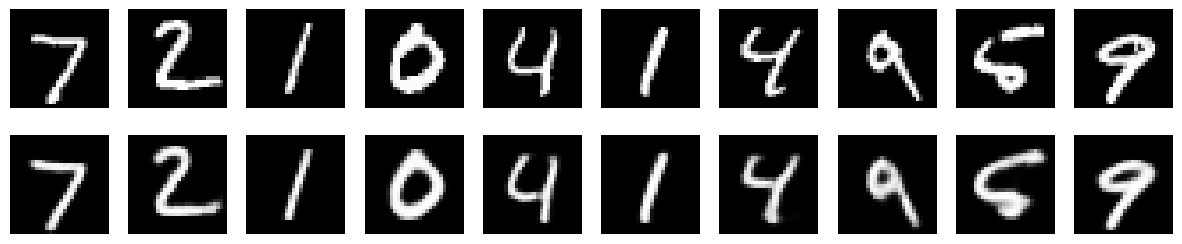

In [ ]:
model.eval()
with torch.no_grad():
    test_data, _ = next(iter(test_loader))
    test_data = test_data.to(device)
    _, _, recon = model(test_data)

    test_data = test_data.cpu()
    recon = recon.cpu()

    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    for i in range(10):
        axes[0, i].imshow(test_data[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
    plt.show()

Давайте попробуем проделать для VAE то же, что и с обычным автоэнкодером -- подсунуть decoder'у из VAE случайные векторы из нормального распределения и посмотреть, какие картинки получаются:

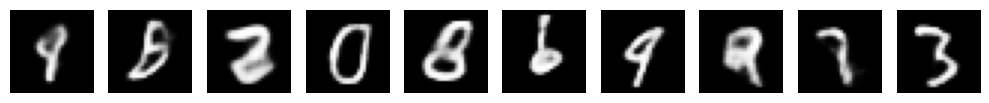

In [ ]:
z = torch.randn(10, 20).to(device)

with torch.no_grad():
    generated = model.decode(z).cpu()

plt.figure(figsize=(10, 2))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(generated[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2.2. Latent Representation (2 балла)

Давайте посмотрим, как латентные векторы картинок лиц выглядят в пространстве.
Ваша задача -- изобразить латентные векторы картинок точками в двумерном просторанстве.

Это позволит оценить, насколько плотно распределены латентные векторы изображений цифр в пространстве.

Плюс давайте сделаем такую вещь: покрасим точки, которые соответствуют картинкам каждой цифры, в свой отдельный цвет

Подсказка: красить -- это просто =) У plt.scatter есть параметр c (color), см. в документации.


Итак, план:
1. Получить латентные представления картинок тестового датасета
2. С помощтю `TSNE` (есть в `sklearn`) сжать эти представления до размерности 2 (чтобы можно было их визуализировать точками в пространстве)
3. Визуализировать полученные двумерные представления с помощью `matplotlib.scatter`, покрасить разными цветами точки, соответствующие картинкам разных цифр.

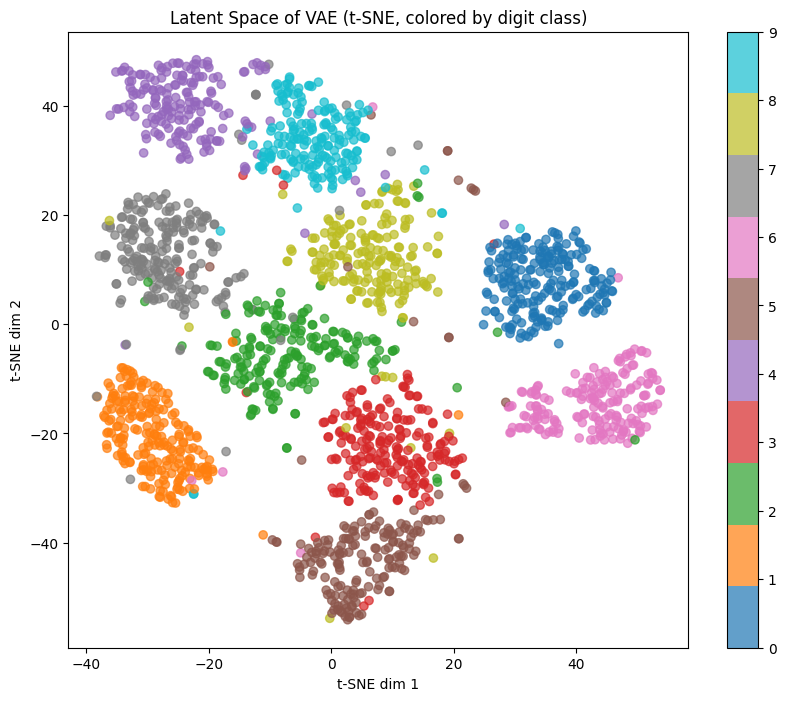

In [ ]:
from sklearn.manifold import TSNE

# Переводим модель в режим оценки
model.eval()

latents = []
labels = []

# Проходим по тестовому датасету
with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        mu, logvar = model.encode(data)  # используем mu как детерминированное латентное представление
        latents.append(mu.cpu())
        labels.append(target)

# Собираем всё в один тензор
latents = torch.cat(latents, dim=0).numpy()  # shape: [N, latent_dim]
labels = torch.cat(labels, dim=0).numpy()    # shape: [N,]

# Применяем t-SNE
n_samples = min(2000, len(latents))
indices = np.random.choice(len(latents), n_samples, replace=False)
latents_subset = latents[indices]
labels_subset = labels[indices]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latents_2d = tsne.fit_transform(latents_subset)

# Визуализация
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels_subset, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title('Latent Space of VAE (t-SNE, colored by digit class)')
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.show()

Что вы думаете о виде латентного представления?

**Ответ:** Каждый класс (0–9) образует свой кластер — значит, VAE научился выделять семантически значимые признаки.

__Congrats v2.0!__

## 2.3. Conditional VAE (6 баллов)


Мы уже научились обучать обычный AE на датасете картинок и получать новые картинки, используя генерацию шума и декодер.
Давайте теперь допустим, что мы обучили AE на датасете MNIST и теперь хотим генерировать новые картинки с числами с помощью декодера (как выше мы генерили рандомные лица).
И вот нам понадобилось сгенерировать цифру 8, и мы подставляем разные варианты шума, но восьмерка никак не генерится:(

Хотелось бы добавить к нашему AE функцию "выдай мне рандомное число из вот этого вот класса", где классов десять (цифры от 0 до 9 образуют десять классов).  Conditional AE — так называется вид автоэнкодера, который предоставляет такую возможность. Ну, название "conditional" уже говорит само за себя.

И в этой части задания мы научимся такие обучать.

### Архитектура

На картинке ниже представлена архитектура простого Conditional VAE.

По сути, единственное отличие от обычного -- это то, что мы вместе с картинкой в первом слое энкодера и декодера передаем еще информацию о классе картинки.

То есть, в первый (входной) слой энкодера подается конкатенация картинки и информации о классе (например, вектора из девяти нулей и одной единицы). В первый слой декодера подается конкатенация латентного вектора и информации о классе.


![alt text](https://sun9-63.userapi.com/impg/Mh1akf7mfpNoprrSWsPOouazSmTPMazYYF49Tw/djoHNw_9KVA.jpg?size=1175x642&quality=96&sign=e88baec5f9bb91c8443fba31dcf0a4df&type=album)

![alt text](https://sun9-73.userapi.com/impg/UDuloLNKhzTBYAKewgxke5-YPsAKyGOqA-qCRg/MnyCavJidxM.jpg?size=1229x651&quality=96&sign=f2d21bfacc1c5755b76868dc4cfef39c&type=album)



На всякий случай: это VAE, то есть, latent у него все еще состоит из mu и sigma

Таким образом, при генерации новой рандомной картинки мы должны будем передать декодеру сконкатенированные латентный вектор и класс картинки.

P.S. Также можно передавать класс картинки не только в первый слой, но и в каждый слой сети. То есть на каждом слое конкатенировать выход из предыдущего слоя и информацию о классе.

In [ ]:
class CVAE(nn.Module):
    def __init__(self):
        super(CVAE, self).__init__()
        self.latent_dim = 20
        self.img_size = 28 * 28
        self.num_classes = 10

        # Encoder
        self.enc_fc1 = nn.Linear(self.img_size + self.num_classes, 512)
        self.enc_fc2 = nn.Linear(512, 256)
        self.fc_mu = nn.Linear(256, self.latent_dim)
        self.fc_logsigma = nn.Linear(256, self.latent_dim)

        # Decoder
        self.dec_fc1 = nn.Linear(self.latent_dim + self.num_classes, 256)
        self.dec_fc2 = nn.Linear(256, 512)
        self.dec_fc3 = nn.Linear(512, self.img_size)

    def encode(self, x, class_num):
        one_hot = F.one_hot(class_num, num_classes=self.num_classes).float()
        x = torch.cat([x.view(-1, self.img_size), one_hot], dim=1)
        h = F.relu(self.enc_fc1(x))
        h = F.relu(self.enc_fc2(h))
        mu = self.fc_mu(h)
        logsigma = self.fc_logsigma(h)
        return mu, logsigma, class_num

    def gaussian_sampler(self, mu, logsigma):
        if self.training:
            std = torch.exp(0.5 * logsigma)
            eps = torch.randn_like(std)
            z = mu + eps * std
            return z
        else:
            return mu

    def decode(self, z, class_num):
        one_hot = F.one_hot(class_num, num_classes=self.num_classes).float()
        z = torch.cat([z, one_hot], dim=1)
        h = F.relu(self.dec_fc1(z))
        h = F.relu(self.dec_fc2(h))
        reconstruction = torch.sigmoid(self.dec_fc3(h))
        reconstruction = reconstruction.view(-1, 1, 28, 28)
        return reconstruction

    def forward(self, x):
        image, class_num = x
        mu, logsigma, class_num = self.encode(image, class_num)
        z = self.gaussian_sampler(mu, logsigma)
        reconstruction = self.decode(z, class_num)
        return mu, logsigma, reconstruction

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cvae = CVAE().to(device)
optimizer = optim.Adam(cvae.parameters(), lr=1e-3)

n_epochs = 20

for epoch in range(n_epochs):
    cvae.train()
    train_loss = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        data = data.to(device)
        target = target.to(device)
        optimizer.zero_grad()
        mu, logsigma, recon = cvae((data, target))
        loss = loss_vae(data, mu, logsigma, recon)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {avg_loss:.4f}')

Epoch 1/20, Loss: 138.6641
Epoch 2/20, Loss: 110.9684
Epoch 3/20, Loss: 106.1995
Epoch 4/20, Loss: 103.7858
Epoch 5/20, Loss: 102.1741
Epoch 6/20, Loss: 101.0888
Epoch 7/20, Loss: 100.1904
Epoch 8/20, Loss: 99.4790
Epoch 9/20, Loss: 99.0007
Epoch 10/20, Loss: 98.4491
Epoch 11/20, Loss: 98.0524
Epoch 12/20, Loss: 97.7241
Epoch 13/20, Loss: 97.4341
Epoch 14/20, Loss: 97.0875
Epoch 15/20, Loss: 96.9182
Epoch 16/20, Loss: 96.6710
Epoch 17/20, Loss: 96.4411
Epoch 18/20, Loss: 96.2543
Epoch 19/20, Loss: 96.0695
Epoch 20/20, Loss: 95.9498


### Sampling


Тут мы будем сэмплировать из CVAE. Это прикольнее, чем сэмплировать из простого AE/VAE: тут можно взять один и тот же латентный вектор и попросить CVAE восстановить из него картинки разных классов!
Для MNIST вы можете попросить CVAE восстановить из одного латентного вектора, например, картинки цифры 5 и 7.


Генерация разных цифр из ОДНОГО латентного вектора:


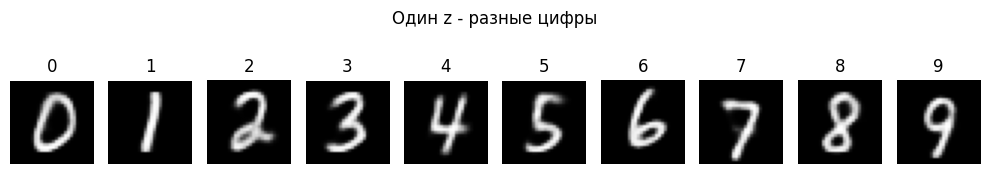

In [ ]:
print("\nГенерация разных цифр из ОДНОГО латентного вектора:")

cvae.eval()
with torch.no_grad():
    z = torch.randn(1, cvae.latent_dim).to(device)

    reconstructions = []
    for digit in range(10):
        class_num = torch.tensor([digit], device=device)  # [1]
        recon = cvae.decode(z, class_num)
        reconstructions.append(recon.cpu())

    plt.figure(figsize=(10, 2))
    for i in range(10):
        plt.subplot(1, 10, i + 1)
        plt.imshow(reconstructions[i][0, 0], cmap='gray')
        plt.title(f'{i}')
        plt.axis('off')
    plt.suptitle('Один z - разные цифры')
    plt.tight_layout()
    plt.show()


Генерация 10 примеров цифры '8':


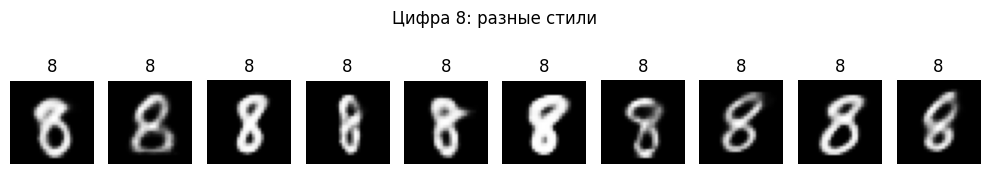

In [ ]:
print("\nГенерация 10 примеров цифры '8':")

digit = 8
n_samples = 10
z = torch.randn(n_samples, cvae.latent_dim).to(device)
class_num = torch.full((n_samples,), digit, dtype=torch.long, device=device)

with torch.no_grad():
    generated = cvae.decode(z, class_num).cpu()

plt.figure(figsize=(10, 2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(generated[i, 0], cmap='gray')
    plt.title(f'{digit}')
    plt.axis('off')
plt.suptitle(f'Цифра {digit}: разные стили')
plt.tight_layout()
plt.show()

Splendid! Вы великолепны!


### Latent Representations

Давайте посмотрим, как выглядит латентное пространство картинок в CVAE и сравним с картинкой для VAE =)

Опять же, нужно покрасить точки в разные цвета в зависимости от класса.

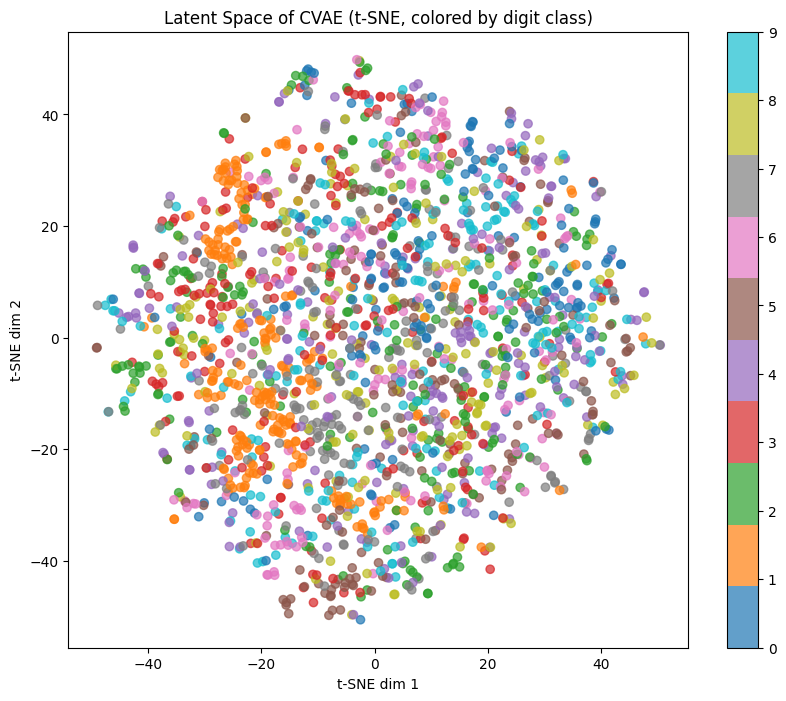

In [ ]:
# Переводим модель в режим оценки
cvae.eval()

latents = []
labels = []

# Проходим по части тестового датасета
with torch.no_grad():
    count = 0
    for data, target in test_loader:
        data = data.to(device)
        target = target.to(device)
        mu, logsigma, _ = cvae.encode(data, target)  # используем mu как латентное представление
        latents.append(mu.cpu())
        labels.append(target.cpu())
        count += data.size(0)
        if count >= 2000:  # ограничим для скорости t-SNE
            break

# Собираем в один массив
latents = torch.cat(latents, dim=0).numpy()
labels = torch.cat(labels, dim=0).numpy()

# Применяем t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latents_2d = tsne.fit_transform(latents)

# Визуализация
plt.figure(figsize=(10, 8))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title('Latent Space of CVAE (t-SNE, colored by digit class)')
plt.xlabel('t-SNE dim 1')
plt.ylabel('t-SNE dim 2')
plt.show()

Что вы думаете насчет этой картинки? Отличается от картинки для VAE?

Ответ: Картинки для СVAE и VAE сильно отличаются. В VAE латентное пространство разделяет классы, модель вынуждена кодировать информацию о классе в латентный вектор, так как у нее нет другого способа различать цифры. В CVAE латентное пространство не разделяет классы явно. Точки разных цифр перемешаны, потому что информация о классе подается отдельно. Модель учится кодировать стиль или вариацию внутри каждого класса, а не сам класс.

# BONUS 1: Denoising (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

У автоэнкодеров, кроме сжатия и генерации изображений, есть другие практические применения. Про одно из них эта бонусная часть задания.

Автоэнкодеры могут быть использованы для избавления от шума на фотографиях (denoising). Для этого их нужно обучить специальным образом: input картинка будет зашумленной, а выдавать автоэнкодер должен будет картинку без шума.
То есть, loss-функция AE останется той же (MSE между реальной картинкой и выданной), а на вход автоэнкодеру будет подаваться зашумленная картинка.

<a href="https://ibb.co/YbRJ1nZ"><img src="https://i.ibb.co/0QD164t/Screen-Shot-2020-06-04-at-4-49-50-PM.png" alt="Screen-Shot-2020-06-04-at-4-49-50-PM" border="0"></a>

Для этого нужно взять ваш любимый датасет (датасет лиц из первой части этого задания или любой другой) и сделать копию этого датасета с шумом.

В питоне шум можно добавить так:

In [ ]:
noise_factor = 0.5
X_noisy = X + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X.shape)

In [ ]:
noise_factor = 0.4

# Добавляем шум и обрезаем до [0, 1]
noisy_train_images = train_images + noise_factor * torch.randn_like(train_images)
noisy_val_images = val_images + noise_factor * torch.randn_like(val_images)

# ВАЖНО: обрезаем значения, чтобы остаться в допустимом диапазоне [0, 1]
noisy_train_images = torch.clamp(noisy_train_images, 0.0, 1.0)
noisy_val_images = torch.clamp(noisy_val_images, 0.0, 1.0)

# Новые датасеты: (зашумлённое изображение, чистое изображение)
train_noisy_dataset = TensorDataset(noisy_train_images, train_images)
val_noisy_dataset = TensorDataset(noisy_val_images, val_images)

train_noisy_loader = DataLoader(train_noisy_dataset, batch_size=32, shuffle=True)
val_noisy_loader = DataLoader(val_noisy_dataset, batch_size=32, shuffle=False)

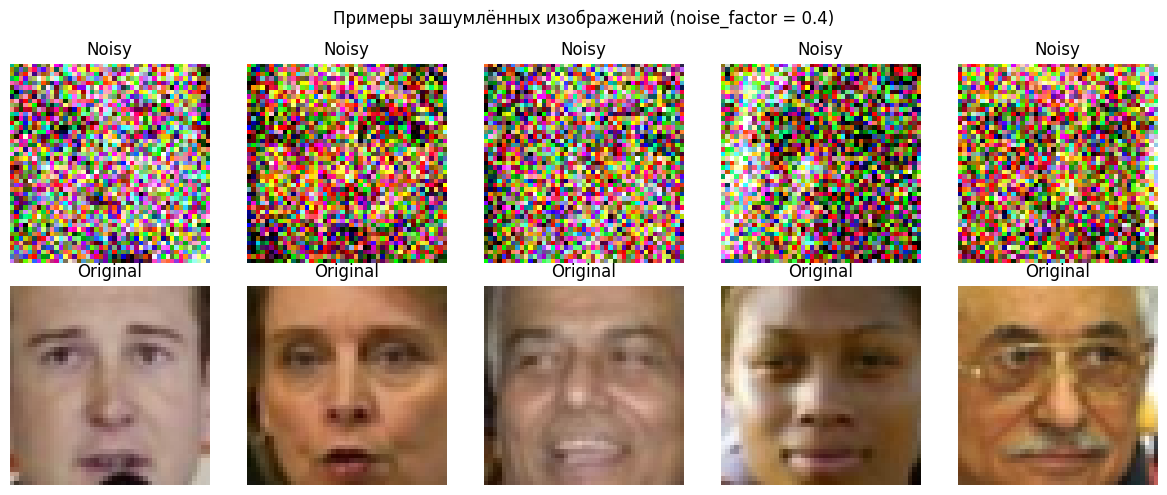

In [ ]:
# Возьмём одну партию из зашумлённого train_loader
noisy_batch, clean_batch = next(iter(train_noisy_loader))

# Покажем первые 5 изображений: зашумлённые и оригиналы
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(5):
    # Зашумлённое изображение
    noisy_img = noisy_batch[i].permute(1, 2, 0).numpy()
    axes[0, i].imshow(noisy_img)
    axes[0, i].set_title("Noisy")
    axes[0, i].axis('off')

    # Оригинал
    clean_img = clean_batch[i].permute(1, 2, 0).numpy()
    axes[1, i].imshow(clean_img)
    axes[1, i].set_title("Original")
    axes[1, i].axis('off')

plt.suptitle(f"Примеры зашумлённых изображений (noise_factor = {noise_factor})")
plt.tight_layout()
plt.show()

In [ ]:
dim_code = 256

class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder: 3 → 32 → 64 → 128 → dim_code
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1),   # 45x45 → 23x23
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 23x23 → 12x12
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), # 12x12 → 6x6
            nn.ReLU(),
            nn.Conv2d(128, dim_code, kernel_size=6, stride=1, padding=0),  # 6x6 → 1x1
            nn.ReLU()
        )
        # Decoder: dim_code → 128 → 64 → 32 → 3
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(dim_code, 128, kernel_size=6, stride=1, padding=0),  # 1x1 → 6x6
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),  # 6x6 → 12x12
            nn.ReLU(),
            # Для 12x12 → 23x23 используем output_padding=0
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=0),  # 12x12 → 23x23
            nn.ReLU(),
            # Для 23x23 → 45x45 используем kernel_size=3, stride=2, padding=1
            nn.ConvTranspose2d(32, 3, kernel_size=3, stride=2, padding=1, output_padding=0),  # 23x23 → 45x45
            nn.Sigmoid()
        )

    def forward(self, x):
        latent = self.encoder(x)
        reconstruction = self.decoder(latent)
        latent_code = latent.view(latent.size(0), -1)
        return reconstruction, latent_code

In [ ]:
# Создаём новую модель
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dae = Autoencoder().to(device)
optimizer = optim.Adam(dae.parameters(), lr=1e-3)
criterion = nn.MSELoss()

n_epochs = 20
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    # Обучение
    dae.train()
    train_loss = 0.0
    for noisy_batch, clean_batch in train_noisy_loader:
        noisy_batch = noisy_batch.to(device)
        clean_batch = clean_batch.to(device)
        optimizer.zero_grad()
        recon, _ = dae(noisy_batch)  # на вход — зашумлённое
        loss = criterion(recon, clean_batch)  # на выходе — чистое
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_noisy_loader)
    train_losses.append(avg_train_loss)

    # Валидация
    dae.eval()
    val_loss = 0.0
    with torch.no_grad():
        for noisy_batch, clean_batch in val_noisy_loader:
            noisy_batch = noisy_batch.to(device)
            clean_batch = clean_batch.to(device)
            recon, _ = dae(noisy_batch)
            loss = criterion(recon, clean_batch)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_noisy_loader)
    val_losses.append(avg_val_loss)

    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}, Train Loss: {avg_train_loss:.6f}, Val Loss: {avg_val_loss:.6f}')

Epoch 5/20, Train Loss: 0.005908, Val Loss: 0.005776
Epoch 10/20, Train Loss: 0.004855, Val Loss: 0.005210
Epoch 15/20, Train Loss: 0.004383, Val Loss: 0.004941
Epoch 20/20, Train Loss: 0.003986, Val Loss: 0.004829


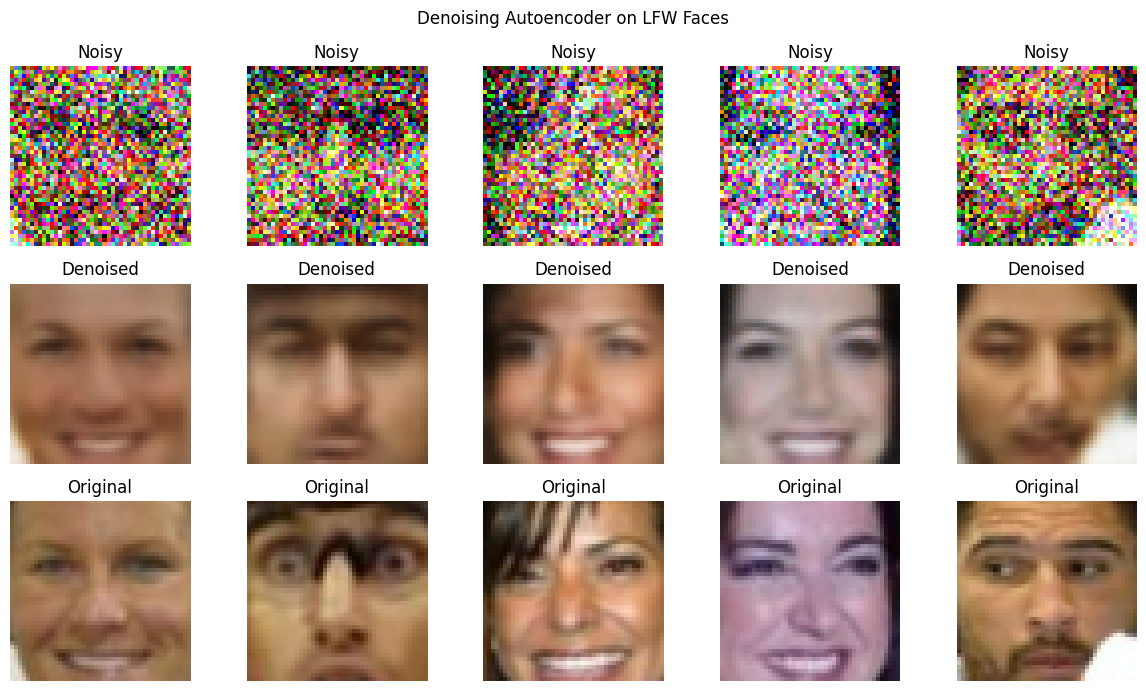

In [ ]:
dae.eval()
with torch.no_grad():
    # Берём первые 5 изображений из валидации
    noisy_sample, clean_sample = next(iter(val_noisy_loader))
    noisy_sample = noisy_sample[:5].to(device)
    clean_sample = clean_sample[:5]

    denoised, _ = dae(noisy_sample)
    denoised = denoised.cpu()

    # Отображаем: зашумлённое | восстановленное | оригинал
    fig, axes = plt.subplots(3, 5, figsize=(12, 7))
    for i in range(5):
        # Noisy
        axes[0, i].imshow(noisy_sample[i].cpu().permute(1, 2, 0))
        axes[0, i].set_title("Noisy")
        axes[0, i].axis('off')

        # Denoised
        axes[1, i].imshow(denoised[i].permute(1, 2, 0))
        axes[1, i].set_title("Denoised")
        axes[1, i].axis('off')

        # Original
        axes[2, i].imshow(clean_sample[i].permute(1, 2, 0))
        axes[2, i].set_title("Original")
        axes[2, i].axis('off')

    plt.suptitle("Denoising Autoencoder on LFW Faces")
    plt.tight_layout()
    plt.show()

# BONUS 2: Image Retrieval (2 балла)

## Внимание! За бонусы доп. баллы не ставятся, но вы можете сделать их для себя.

Давайте представим, что весь наш тренировочный датасет -- это большая база данных людей. И вот мы получили картинку лица какого-то человека с уличной камеры наблюдения (у нас это картинка из тестового датасета) и хотим понять, что это за человек. Что нам делать? Правильно -- берем наш VAE, кодируем картинку в латентное представление и ищем среди латентных представлений лиц нашей базы самые ближайшие!

План:

1. Получаем латентные представления всех лиц тренировочного датасета
2. Обучаем на них LSHForest `(sklearn.neighbors.LSHForest)`, например, с `n_estimators=50`
3. Берем картинку из тестового датасета, с помощью VAE получаем ее латентный вектор
4. Ищем с помощью обученного LSHForest ближайшие из латентных представлений тренировочной базы
5. Находим лица тренировочного датасета, которым соответствуют ближайшие латентные представления, визуализируем!

Немного кода вам в помощь: (feel free to delete everything and write your own)

In [ ]:
class FaceVAE(nn.Module):
    def __init__(self, latent_dim=512):
        super(FaceVAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),    # 45 → 22
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),   # 22 → 11
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),  # 11 → 5
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 5 * 5, latent_dim * 2)       # mu и logvar вместе
        )

        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, 128 * 5 * 5)
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1, output_padding=1),  # 5 → 11
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1, output_padding=1),   # 11 → 23
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1, output_padding=1),    # 23 → 47 → проблема!
        )

    def encode(self, x):
        h = self.encoder(x)
        mu, logvar = h.chunk(2, dim=1)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(h.size(0), 128, 5, 5)
        h = self.decoder_conv(h)
        h = F.interpolate(h, size=(45, 45), mode='bilinear', align_corners=False)
        return torch.sigmoid(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_rec = self.decode(z)
        return mu, logvar, x_rec

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
face_vae = FaceVAE().to(device)
optimizer = optim.Adam(face_vae.parameters(), lr=1e-3)

def vae_loss(x, mu, logvar, x_rec):
    recon_loss = F.mse_loss(x_rec, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_loss

n_epochs = 30
for epoch in range(n_epochs):
    face_vae.train()
    total_loss = 0
    for batch in train_loader:
        x = batch[0].to(device)
        optimizer.zero_grad()
        mu, logvar, x_rec = face_vae(x)
        loss = vae_loss(x, mu, logvar, x_rec)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_loader):.4f}')

Epoch 1/30, Loss: 4418.6812
Epoch 2/30, Loss: 3171.1385
Epoch 3/30, Loss: 3042.1493
Epoch 4/30, Loss: 2988.1007
Epoch 5/30, Loss: 2924.4674
Epoch 6/30, Loss: 2879.0496
Epoch 7/30, Loss: 2804.2951
Epoch 8/30, Loss: 2715.3405
Epoch 9/30, Loss: 2620.2717
Epoch 10/30, Loss: 2528.2607
Epoch 11/30, Loss: 2490.2810
Epoch 12/30, Loss: 2456.2582
Epoch 13/30, Loss: 2427.0933
Epoch 14/30, Loss: 2402.8538
Epoch 15/30, Loss: 2374.5692
Epoch 16/30, Loss: 2354.6311
Epoch 17/30, Loss: 2337.1024
Epoch 18/30, Loss: 2324.5656
Epoch 19/30, Loss: 2313.5561
Epoch 20/30, Loss: 2296.0288
Epoch 21/30, Loss: 2279.5552
Epoch 22/30, Loss: 2262.6896
Epoch 23/30, Loss: 2256.8487
Epoch 24/30, Loss: 2239.7068
Epoch 25/30, Loss: 2226.4159
Epoch 26/30, Loss: 2221.8017
Epoch 27/30, Loss: 2214.2206
Epoch 28/30, Loss: 2209.5471
Epoch 29/30, Loss: 2201.1006
Epoch 30/30, Loss: 2199.8965


In [ ]:
# face_vae — обученная модель
face_vae.eval()
codes = []

with torch.no_grad():
    for batch in DataLoader(TensorDataset(train_images, train_attrs), batch_size=64, shuffle=False):
        x = batch[0].to(device)
        mu, _ = face_vae.encode(x)  # используем mu как детерминированный код
        codes.append(mu.cpu())

codes = torch.cat(codes, dim=0).numpy()
codes = codes / (np.linalg.norm(codes, axis=1, keepdims=True) + 1e-8)
print("Latent codes shape:", codes.shape)

Latent codes shape: (11828, 512)


In [ ]:
from sklearn.neighbors import NearestNeighbors

class LSHForest:
    def __init__(self, n_estimators=50, random_state=None):
        self.nn = NearestNeighbors(metric='euclidean', algorithm='brute')
    def fit(self, X):
        self.nn.fit(X)
        return self
    def kneighbors(self, X, n_neighbors=5):
        return self.nn.kneighbors(X, n_neighbors=n_neighbors)

lshf = LSHForest().fit(codes)

In [ ]:
def get_similar(image, n_neighbors=5):

    face_vae.eval()
    with torch.no_grad():
        # Получаем латентный код
        x = image.unsqueeze(0).to(device)
        code, _ = face_vae.encode(x)
        code = code.cpu().numpy()

    # Поиск ближайших с помощью LSHForest
    distances, indices = lshf.kneighbors(code, n_neighbors=n_neighbors)

    # distances: [1, n_neighbors], indices: [1, n_neighbors]
    # Берём из train_images по индексам
    neighbors = train_images[indices[0]]  # [n_neighbors, 3, 45, 45]

    return distances[0], neighbors

In [ ]:
def show_similar(image):
    distances, neighbors = get_similar(image, n_neighbors=11)

    plt.figure(figsize=[12, 5])
    plt.subplot(3, 4, 1)
    plt.imshow(image.cpu().numpy().transpose([1, 2, 0]))
    plt.title("Original image")
    plt.axis('off')

    for i in range(11):
        plt.subplot(3, 4, i + 2)
        plt.imshow(neighbors[i].cpu().numpy().transpose([1, 2, 0]))
        plt.title("Dist=%.3f" % distances[i])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

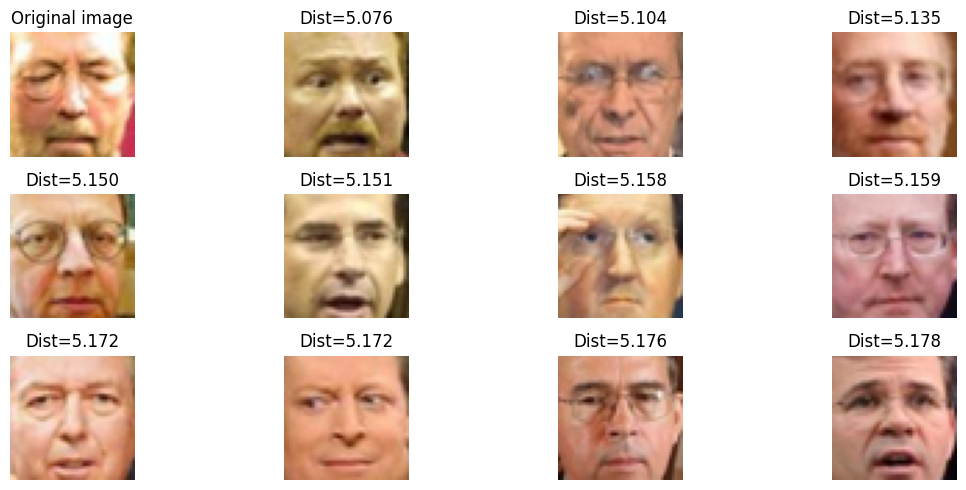

In [ ]:
test_image = val_images[8]

show_similar(test_image)

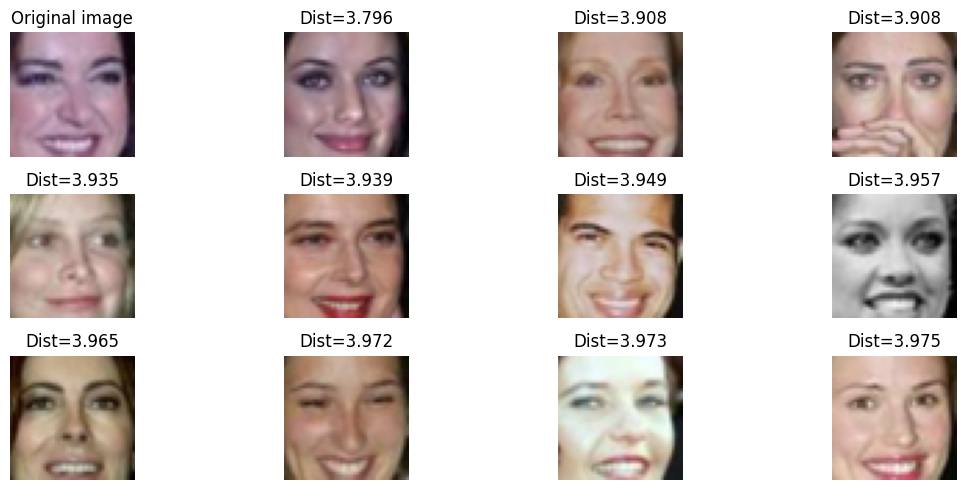

In [ ]:
test_image = val_images[3]

show_similar(test_image)